In [2]:
import pandas as pd

In [3]:
order_df = pd.read_parquet("../data/raw_data/order_dataset.parquet")

In [4]:
order_df.head(3)

,dt,customer_id,order_id,product_id,category,soi_store_language,market,device,ordered_qty,revenue
0,2025-06-03,A7B95A7808EF0C16E7CF42D7445F1EB582C86909EA432F...,C02908174B638574EE4F09F88CF55100A0F620E96B2DC0...,8044018441810B0998F6B85E1FAE2C072DEBFE85D8A163...,Category_B,Arabic,Market_B,ios,1,2142.223303
1,2023-10-08,F004B90B022AF8DA79154CF4AAE7B824D358D3FA76754E...,2ECD06FA227B86C0B6EEFD4A734C8488BB1429EDF7396F...,C899B2B6502245DE729B863F1BC7A5AEA04DE969A65493...,Category_A,Arabic,Market_B,ios,1,1501.687215
2,2025-02-11,6F7FC2955813243BA00C048A710F2EEDD95D46EAA26C60...,20ED9567E22B5AB96C3D61159FCD03834CF05245BFE651...,3659C13572C1762B68F771068E3DD6A61014933F779758...,Category_B,Arabic,Market_A,ios,1,5755.449764


In [5]:
order_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10536112 entries, 0 to 10536111
Data columns (total 10 columns):
 #   Column              Dtype  
---  ------              -----  
 0   dt                  object 
 1   customer_id         str    
 2   order_id            str    
 3   product_id          str    
 4   category            str    
 5   soi_store_language  str    
 6   market              str    
 7   device              str    
 8   ordered_qty         int64  
 9   revenue             float64
dtypes: float64(1), int64(1), object(1), str(7)
memory usage: 2.9+ GB


In [6]:
order_df.category.value_counts()

category
Category_D    4610565
Category_A    3706948
Category_F    1027851
Category_B     875581
Category_C     315167
Name: count, dtype: int64

In [7]:
order_df.market.value_counts()

market
Market_A    7161237
Market_B    3374875
Name: count, dtype: int64

In [8]:
order_df.device.value_counts()

device
ios          9522694
web           766303
android       223559
web-admin      23556
Name: count, dtype: int64

## notes

In [ ]:
"""
PART 1 — DATA STRUCTURING ASSUMPTIONS
======================================

TARGET & GRANULARITY
- Target variable: net revenue (sum of revenue column, excluding cancelled rows)
- Modeling granularity: weekly (prior) — empirically validated post-preprocessing
  against daily, evaluated at monthly level
- OTB consumption level: monthly — weekly predictions aggregated up

POPULATION SEPARATION
- Two distinct data generating processes:
    consumer  → is_bulk_buyer = False
    bulk      → is_bulk_buyer = True
- Business account classification (customer-level, not transaction-level):
    bulk order = qty > 10
    business account = bulk_order_count > 2 AND bulk_order_frequency > 0.5
- Confirmed via attribute inspection: 11 customers, structured high-volume
  purchasing patterns inconsistent with individual luxury consumer behavior
- Bulk population too sparse for standalone model regardless of threshold tuning
- Both populations included in unified series — bulk presence captured as covariate
- bulk_order_count per period at date × category × market granularity

SERIES CONSTRUCTION
- Output: one base table at date × category × market granularity
- Construction pipeline:
    1. Flag cancelled rows (revenue == 0) as is_cancelled pre-aggregation
    2. groupby date × category × market →
          revenue sum (non-cancelled rows only)
          cancelled_order_count (sum of is_cancelled)
          bulk_order_count (sum of is_bulk_buyer)
    3. Generate full cartesian product: all weeks × categories × markets
    4. Left join aggregated data onto cartesian
    5. Fill gaps with zero — zero = absent demand, not missing data
- Downstream modeling tasks consume this single base table differently:
    global model  → full table, category/market as encoded features
    bottom-up     → table split into 10 independent series by category × market

RETURNS
- Only 1 negative revenue row in 10M+ records — returns are not encoded as
  negative revenue in this dataset
- Zero revenue rows (18% of data) likely represent cancelled orders —
  qty is recorded but transaction did not complete
- Zero revenue rows flagged as is_cancelled, excluded from revenue aggregation
- cancelled_order_count retained as post-aggregation covariate per period
- Return count feature dropped — no viable signal to engineer from this dataset
- Production note: a robust implementation would incorporate a dedicated returns
  feed as a separate covariate. Return activity is a meaningful demand signal
  in luxury e-commerce and its absence is a data architecture limitation,
  not a modeling choice

FEATURE ENGINEERING
- Ramadan: exponential weight 0→1 across period — (exp(x)-1)/(e-1)
  hardcoded dates per year from published Islamic calendar
- Eid al-Fitr: binary flag days 1, 2, 3
- Eid al-Adha: binary flag days 1, 2, 3 (~70 days after Eid al-Fitr)
- Market A (UAE): National Day (Dec 2), DSF window (Jan 15 — Feb 15 approx)
- Market B (KSA): National Day (Sep 23), Founding Day (Feb 22)
- Cross-market: New Year (Jan 1), Christmas window (Dec 24-26)
- Standard: week of year, month, quarter, is_weekend (Fri=4, Sat=5 in GCC)
- All features forward-generatable — zero leakage risk on 12-month forecast horizon
- store_language dropped — no signal beyond what market already captures

MODELING ARCHITECTURE

TASK 1 — OVERALL FORECAST (Global Model)
- All 10 category × market series stacked vertically
- Category and market encoded as features (label or one-hot)
- One model learns cross-series relationships simultaneously
- Output: aggregate revenue forecast for OTB budget envelope

TASK 2 — CATEGORY × MARKET FORECAST (Bottom-Up)
- 10 independent series, one model per series
- Each series sees only its own revenue trajectory + calendar features
- Output: per-combination forecasts for inventory allocation decisions

DATA PREPARATION
- Both tasks derived from the same aggregated base table
- Divergence happens at modeling stage, not aggregation stage:
    global model  → full stacked table, category/market as encoded columns
    bottom-up     → table split into 10 independent dataframes per series

NOTEBOOK STRUCTURE
- Tab 1: data engineering (shared base, feeds both)
- Tab 2: bottom-up models (category × market)
- Tab 3: global model (overall)
"""

'\nPART 1 — DATA STRUCTURING ASSUMPTIONS\n======================================\n\nTARGET & GRANULARITY\n- Target variable: net revenue (sum of revenue column including negatives)\n- Modeling granularity: weekly (prior) — empirically validated post-preprocessing\n  against daily, evaluated at monthly level\n- OTB consumption level: monthly — weekly predictions aggregated up\n\nPOPULATION SEPARATION\n- Two distinct data generating processes:\n    consumer  → qty <= 15\n    bulk      → any order with qty > 15\n- Bulk confirmed via attribute inspection: structured, high-volume, concentrated\n  purchasing patterns inconsistent with individual luxury consumer behavior\n- Both populations included in OTB forecast — bulk revenue is real, recurring,\n  and material to planning budget\n- Modeled separately, unified at output:\n    final OTB forecast = consumer forecast + bulk forecast (aggregated to monthly)\n- Uncertainty decomposed separately — consumer is more predictable, bulk is episodic\

## understanding order behaviour
Do we have different data generating processes? Are some customers business accounts?

In [9]:
order_df.ordered_qty.value_counts() ### what are these bulk orders? Opportunity for feature engineering?

ordered_qty
1      10334058
2        114665
3         60926
4         13387
5          5748
         ...   
104           1
125           1
137           1
130           1
126           1
Name: count, Length: 67, dtype: int64

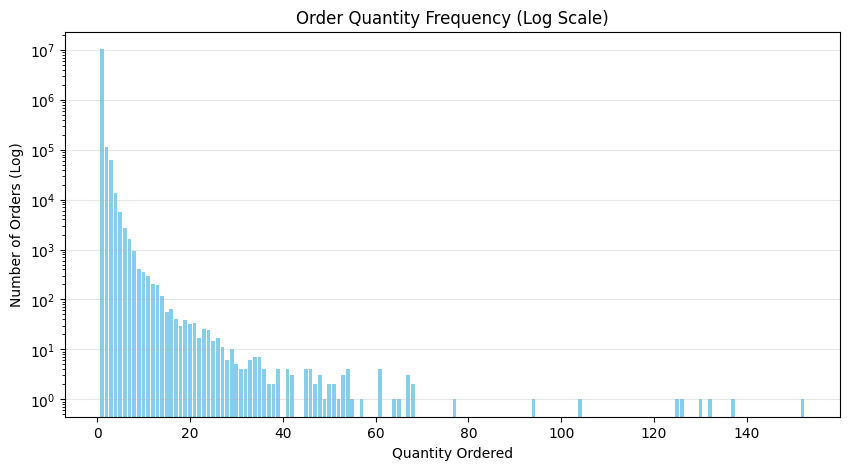

Top 5 Quantities by Volume:
ordered_qty
1    10334058
2      114665
3       60926
4       13387
5        5748
Name: count, dtype: int64


In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. AGGREGATE FIRST (This is the secret to speed)
# value_counts() is highly optimized C/Rust code; it handles 10M rows instantly.
counts = order_df['ordered_qty'].value_counts().sort_index()

# 2. Filter for the "Head" and "Tail"
# Most of your data is between 1 and 50.
plot_data = counts[counts.index <= 250]

# 3. Simple Matplotlib Plot (much faster than Seaborn for large pre-aggregated data)
plt.figure(figsize=(10, 5))
plt.bar(plot_data.index, plot_data.values, color='skyblue', log=True) # Log scale is key!

plt.title('Order Quantity Frequency (Log Scale)')
plt.xlabel('Quantity Ordered')
plt.ylabel('Number of Orders (Log)')
plt.grid(axis='y', alpha=0.3)
plt.show()

# 4. Quick Percentile Check (No Plotting needed)
print("Top 5 Quantities by Volume:")
print(counts.head(5))

In [54]:
potential_business_accounts = order_df[order_df.ordered_qty > 10].customer_id.value_counts()

In [55]:
business_account_order_df = order_df[
    order_df.customer_id.isin(potential_business_accounts.keys())
]

In [56]:
business_account_order_df.category.value_counts()


category
Category_A    45872
Category_D    38768
Category_F     7470
Category_B     5725
Category_C     1286
Name: count, dtype: int64

In [57]:
business_account_order_df.head(1)

,dt,customer_id,order_id,product_id,category,soi_store_language,market,device,ordered_qty,revenue
184,2025-01-10,57E1BEBC64574E17B4286044A3BA567508EA953E98F073...,A9C987CDDB00D5FA736969A7AC68CCD48EA6FE1B5FE78D...,825EF525DF0A0CB7C348394688F9AB2FA462A3C1F2134B...,Category_D,English,Market_A,ios,1,0.0


In [59]:
business_account_order_df.groupby("customer_id").agg(
    ordered_qty_sum=('ordered_qty', 'sum'),
    revenue_total=('revenue', 'sum'),

    market_A_count=('market', lambda x: (x == "Market_A").sum()),
    market_B_count=('market', lambda x: (x == "Market_B").sum()),

    category_A_count=('category', lambda x: (x == "Category_A").sum()),
    category_B_count=('category', lambda x: (x == "Category_B").sum()),
    category_C_count=('category', lambda x: (x == "Category_C").sum()),
    category_D_count=('category', lambda x: (x == "Category_D").sum()),
    category_F_count=('category', lambda x: (x == "Category_F").sum()),

    category_total=('category', 'count')
).sort_values(by="ordered_qty_sum").reset_index()

,customer_id,ordered_qty_sum,revenue_total,market_A_count,market_B_count,category_A_count,category_B_count,category_C_count,category_D_count,category_F_count,category_total
0,6D015EC216B3C4805CDE11512E85939BFD9E47A6C7A39B...,11,1.548580e+03,1,0,0,0,0,1,0,1
1,8CD9082E462C110ED5063EE203A0A7C7DEAEF08BD83421...,11,1.414945e+04,1,0,0,0,0,0,1,1
2,1E3B271DBFC009C83E762F158589CC2D1D811ADB6CCD21...,11,1.334702e+04,1,0,1,0,0,0,0,1
3,4B5617E2904AD622CAF865C666C0A7F5EA5CCAE96EF68E...,11,1.080866e+04,1,0,0,0,0,1,0,1
4,918834B7DE5BA7ED012A769D9E7E9F5F2949AE6E331E04...,11,6.884920e+03,1,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
724,8D5BB7BF51CBE5A396E5F636B9AF15B7AEAF43913C55C7...,2959,1.086646e+07,2464,0,1082,202,53,822,305,2464
725,86F7B571D88A5E7CC9CA0EF627E5DF2E72D82A14546FD9...,3549,1.051636e+06,231,0,204,4,0,22,1,231
726,48AD0C3566619366E9DBCD0BADE06E090630A1F2D29EC7...,4622,2.498549e+06,1873,0,1863,0,0,10,0,1873
727,524E7AEB0CC5E043396CA0E8BE248D0AACCE9353F45A2D...,4741,3.237461e+06,3871,0,3025,1,1,840,4,3871


## understanding revenue

<Axes: >

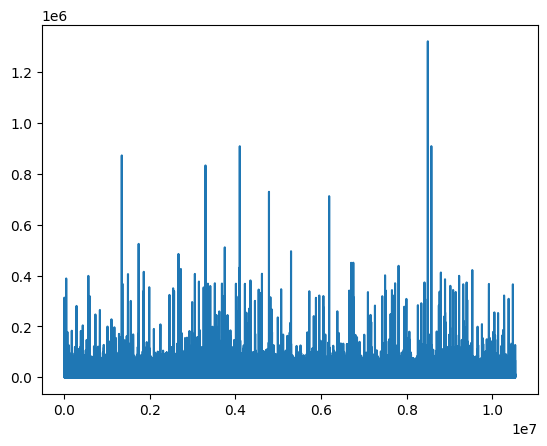

In [11]:
order_df.revenue.plot()

In [12]:
order_df.revenue.describe() # negative rev? Loss?

count    1.053611e+07
mean     1.966239e+03
std      3.605772e+03
min     -3.408739e-02
25%      3.452119e+02
50%      8.897148e+02
75%      2.230992e+03
max      1.322029e+06
Name: revenue, dtype: float64

## null value check

In [18]:
order_df.isnull().sum()

dt                    0
customer_id           0
order_id              0
product_id            0
category              0
soi_store_language    0
market                0
device                0
ordered_qty           0
revenue               0
dtype: int64

## quick seasionality check

In [44]:
sorted_orders = order_df.sort_values(by="dt")

<Axes: xlabel='dt'>

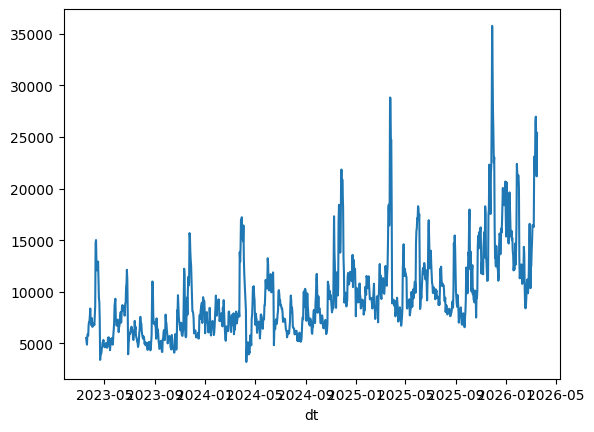

In [45]:
sorted_orders.groupby("dt").ordered_qty.count().plot()

## feature engineering

### utils

In [ ]:
import numpy as np
import pandas as pd

# ── Islamic Calendar (shared across all markets) ──────────────────────────────

RAMADAN_PERIODS = {
    2023: ("2023-03-23", "2023-04-20"),
    2024: ("2024-03-11", "2024-04-09"),
    2025: ("2025-03-01", "2025-03-30"),
    2026: ("2026-02-18", "2026-03-19"),
}

EID_AL_FITR = {
    2023: ["2023-04-21", "2023-04-22", "2023-04-23"],
    2024: ["2024-04-10", "2024-04-11", "2024-04-12"],
    2025: ["2025-03-31", "2025-04-01", "2025-04-02"],
    2026: ["2026-03-20", "2026-03-21", "2026-03-22"],
}

EID_AL_ADHA = {
    2023: ["2023-06-28", "2023-06-29", "2023-06-30"],
    2024: ["2024-06-16", "2024-06-17", "2024-06-18"],
    2025: ["2025-06-06", "2025-06-07", "2025-06-08"],
    2026: ["2026-05-27", "2026-05-28", "2026-05-29"],
}

# ── Market-Specific National Holidays ─────────────────────────────────────────

MARKET_HOLIDAYS = {
    "Market_A": {  # UAE
        "national_day":   ["12-02"],          # UAE National Day
        "dsf_start":      ["01-15"],          # Dubai Shopping Festival (approx window start)
        "dsf_end":        ["02-15"],          # Dubai Shopping Festival (approx window end)
    },
    "Market_B": {  # Saudi Arabia
        "national_day":   ["09-23"],          # Saudi National Day
        "founding_day":   ["02-22"],          # Saudi Founding Day
    },
}

# ── Cross-Market Western Calendar Events ──────────────────────────────────────

WESTERN_EVENTS = {
    "new_year":       ["01-01"],
    "christmas":      ["12-24", "12-25", "12-26"],
}

# ── Feature Engineering Functions ─────────────────────────────────────────────

def add_ramadan_weight(df, date_col="dt"):
    """
    Exponential weight 0→1 across Ramadan period.
    Outside Ramadan = 0.
    """
    df = df.copy()
    df["ramadan_weight"] = 0.0

    for year, (start, end) in RAMADAN_PERIODS.items():
        start_dt = pd.Timestamp(start)
        end_dt   = pd.Timestamp(end)
        mask     = (df[date_col] >= start_dt) & (df[date_col] <= end_dt)
        duration = (end_dt - start_dt).days

        positions = (df.loc[mask, date_col] - start_dt).dt.days / duration  # 0→1
        df.loc[mask, "ramadan_weight"] = (np.exp(positions) - 1) / (np.e - 1)  # normalized exp

    return df


def add_eid_flags(df, date_col="dt"):
    """Binary flags for Eid al-Fitr and Eid al-Adha (days 1-3)."""
    df = df.copy()
    fitr_dates  = pd.to_datetime([d for days in EID_AL_FITR.values()  for d in days])
    adha_dates  = pd.to_datetime([d for days in EID_AL_ADHA.values()  for d in days])

    df["is_eid_fitr"] = df[date_col].isin(fitr_dates).astype(int)
    df["is_eid_adha"] = df[date_col].isin(adha_dates).astype(int)
    return df


def add_market_holidays(df, date_col="dt", market_col="market"):
    """Market-specific national holiday flags."""
    df = df.copy()
    df["is_national_day"] = 0
    df["is_founding_day"] = 0
    df["is_dsf_window"]   = 0

    for year in df[date_col].dt.year.unique():
        # UAE National Day
        uae_mask = (
            (df[market_col] == "Market_A") &
            (df[date_col] == pd.Timestamp(f"{year}-12-02"))
        )
        df.loc[uae_mask, "is_national_day"] = 1

        # Saudi National Day
        ksa_nd_mask = (
            (df[market_col] == "Market_B") &
            (df[date_col] == pd.Timestamp(f"{year}-09-23"))
        )
        df.loc[ksa_nd_mask, "is_national_day"] = 1

        # Saudi Founding Day
        ksa_fd_mask = (
            (df[market_col] == "Market_B") &
            (df[date_col] == pd.Timestamp(f"{year}-02-22"))
        )
        df.loc[ksa_fd_mask, "is_founding_day"] = 1

        # DSF window (Market A only, Jan 15 - Feb 15 approx)
        dsf_mask = (
            (df[market_col] == "Market_A") &
            (df[date_col] >= pd.Timestamp(f"{year}-01-15")) &
            (df[date_col] <= pd.Timestamp(f"{year}-02-15"))
        )
        df.loc[dsf_mask, "is_dsf_window"] = 1

    return df


def add_western_events(df, date_col="dt"):
    """New Year and Christmas window flags."""
    df = df.copy()
    df["is_new_year"]  = (
        (df[date_col].dt.month == 1) & (df[date_col].dt.day == 1)
    ).astype(int)
    df["is_christmas"] = (
        (df[date_col].dt.month == 12) & (df[date_col].dt.day.isin([24, 25, 26]))
    ).astype(int)
    return df


def add_calendar_features(df, date_col="dt"):
    """Standard calendar features. Note: GCC weekend is Fri-Sat."""
    df = df.copy()
    df["week_of_year"] = df[date_col].dt.isocalendar().week.astype(int)
    df["month"]        = df[date_col].dt.month
    df["quarter"]      = df[date_col].dt.quarter
    df["is_weekend"]   = df[date_col].dt.dayofweek.isin([4, 5]).astype(int)  # Fri=4, Sat=5
    return df


def build_all_features(df, date_col="dt", market_col="market"):
    """Master function — apply full feature pipeline."""
    df = add_ramadan_weight(df, date_col)
    df = add_eid_flags(df, date_col)
    df = add_market_holidays(df, date_col, market_col)
    df = add_western_events(df, date_col)
    df = add_calendar_features(df, date_col)
    return df